In [5]:

import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import h5py
import numpy as np 


from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator


In [2]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/experiment/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    broadened_dos_normalized = broadened_dos / broadened_area
    return 3*unit_cell_atoms*broadened_dos_normalized

def read_timeseries(filename):
    print("oppening %s"%filename)
    h5file=h5py.File(filename)
    data_dict=dict()
    for k in h5file.keys():
        units=h5file[k].attrs['units']
        data_dict["%s (%s)"%(k.replace("_"," "),units)]=h5file[k][:]
    df_tmp=pd.DataFrame(data_dict)
    df_tmp=df_tmp.drop(columns=[x for x in df_tmp.columns if "group" in x])
    df_tmp['time (ns)']=df_tmp['time (ps)']*0.001
    return df_tmp


In [3]:
def read_dos(filename,emin,emax,apply_broadening=False):
    h5file=h5py.File(filename)
    data_dict=dict()
    omega_shape=h5file["omega"][:].shape
    for k in h5file.keys():
        data_array=h5file[k][:]
        if data_array.shape != omega_shape or "_0" in k:
            continue
        units=h5file[k].attrs['units']
        data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
    df_tmp=pd.DataFrame(data_dict).query("%f <= `omega (rad/ps)` and `omega (rad/ps)` < %f"%(emin/0.6582,emax/0.6582))
    df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
    if apply_broadening:
        df_tmp['dos total (nm2/ps)']=apply_gaussian_broadening(df_tmp)
    df_tmp["Phonon Density of States"]=df_tmp['dos total (nm2/ps)']/df_tmp['dos total (nm2/ps)'].max()
    return df_tmp

emin=1
emax=150
df_list=list()
for timestep in [0.0005,0.001,0.002]:
    results_directory="../results/lammps/convergence/2nm/timestep/results/dt_%s/mdanse/nvt_phonon_100K_dos.h5"%str(timestep)
    df_tmp=read_dos(results_directory,emin,emax,apply_broadening=True)
    df_tmp["Timestep (fs)"]=timestep*1000
    df_list.append(df_tmp)

df_dos_dt=pd.concat(df_list,ignore_index=True)

df_list=list()
for timestep in [0.0005,0.001,0.002]:
    results_directory="../results/lammps/convergence/2nm/timestep/results/dt_%s/mdanse/nvt_prod_100K_rmsd.h5"%str(timestep)
    df_tmp=read_timeseries(results_directory)
    df_tmp["Timestep (fs)"]=timestep*1000
    df_list.append(df_tmp)

df_rmsd=pd.concat(df_list,ignore_index=True)



df_list=list()
for timestep in [0.0005,0.001,0.002]:
    results_directory="../results/lammps/convergence/2nm/timestep/results/dt_%s/nvt_prod_100K_rog/rog.csv"%str(timestep)
    df_tmp=pd.read_csv(results_directory)
    df_tmp["Timestep (fs)"]=timestep*1000
    df_tmp["Time (ns)"]=df_tmp["Time (ps)"]*0.001
    df_list.append(df_tmp)

df_rog=pd.concat(df_list,ignore_index=True)
display(df_rog)


df_list=list()
for timestep in [0.0005,0.001,0.002]:
    results_directory="../results/lammps/convergence/2nm/timestep/results/dt_%s/mdanse/nvt_prod_100K_ecc.h5"%str(timestep)
    df_tmp=read_timeseries(results_directory)
    df_tmp["Timestep (fs)"]=timestep*1000
    df_list.append(df_tmp)

df_ecc=pd.concat(df_list,ignore_index=True)

oppening ../results/lammps/convergence/2nm/timestep/results/dt_0.0005/mdanse/nvt_prod_100K_rmsd.h5
oppening ../results/lammps/convergence/2nm/timestep/results/dt_0.001/mdanse/nvt_prod_100K_rmsd.h5
oppening ../results/lammps/convergence/2nm/timestep/results/dt_0.002/mdanse/nvt_prod_100K_rmsd.h5


,Time (ps),Radius (nm),Timestep (fs),Time (ns)
0,0,1.56464,0.5,0.000
1,1,1.56502,0.5,0.001
2,2,1.56485,0.5,0.002
3,3,1.56452,0.5,0.003
4,4,1.56517,0.5,0.004
...,...,...,...,...
14995,4995,1.56505,2.0,4.995
14996,4996,1.56494,2.0,4.996
14997,4997,1.56499,2.0,4.997
14998,4998,1.56468,2.0,4.998


oppening ../results/lammps/convergence/2nm/timestep/results/dt_0.0005/mdanse/nvt_prod_100K_ecc.h5
oppening ../results/lammps/convergence/2nm/timestep/results/dt_0.001/mdanse/nvt_prod_100K_ecc.h5
oppening ../results/lammps/convergence/2nm/timestep/results/dt_0.002/mdanse/nvt_prod_100K_ecc.h5


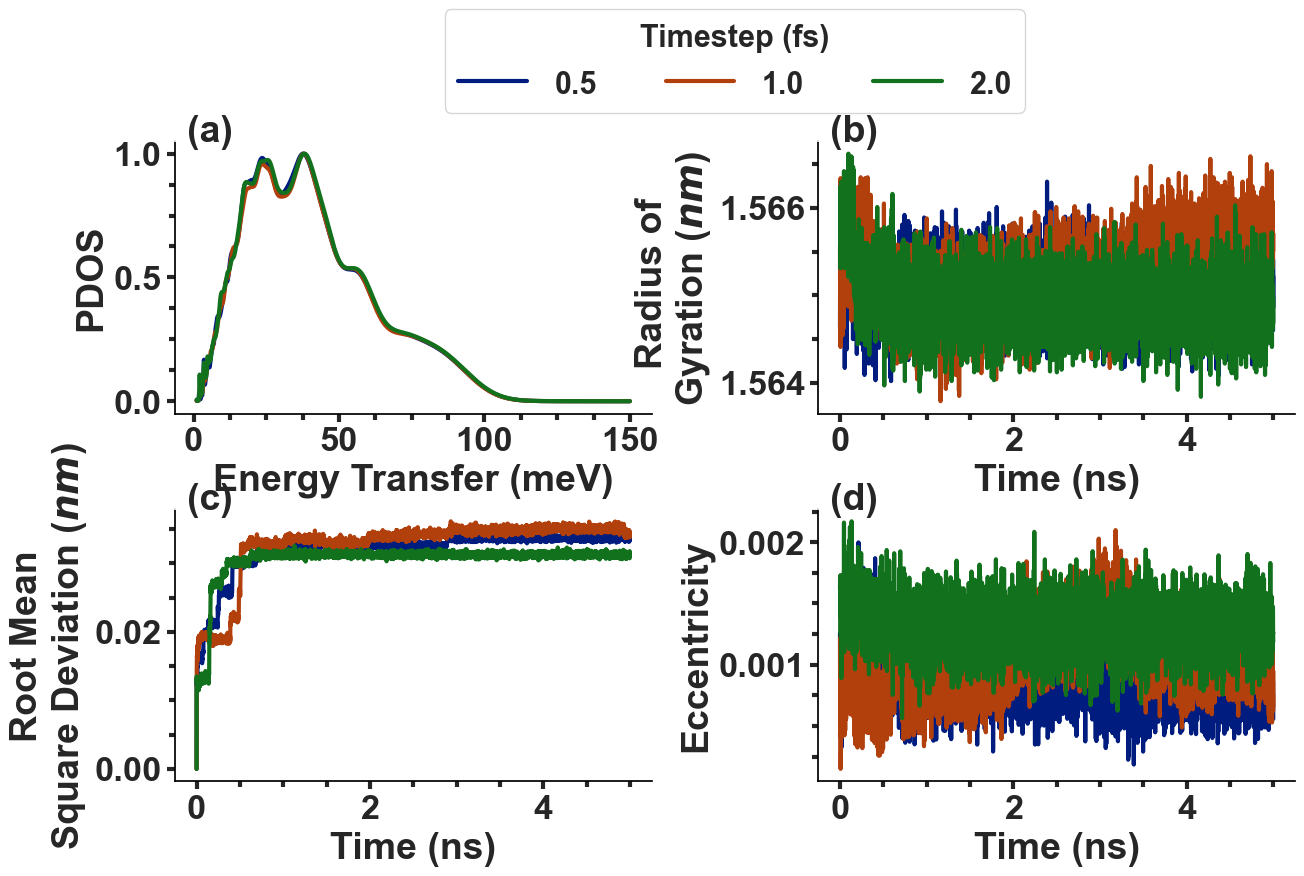

In [11]:
plt.rc('axes', linewidth=6, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")

fig, axs = plt.subplots(ncols=2,nrows=2,figsize=(7*2,4*2))


labx=0.025
laby=1

ax=axs[0,0]
ax.text(labx, laby, '(a)',weight='bold' ,transform=ax.transAxes)
sns.lineplot(data=df_dos_dt.query("%f <= `Energy Transfer (meV)` and `Energy Transfer (meV)` <= %f "%(emin,emax))
    , y='Phonon Density of States'
             , x='Energy Transfer (meV)'
             ,ax=ax
             ,hue="Timestep (fs)"
             ,palette='dark'
             ,lw=3
       )
sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1),ncol=3,bbox_transform=fig.transFigure)
plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title

ax.spines['bottom'].set_color('0')
ax.spines['top'].set_color('1')
ax.spines['right'].set_color('1')
ax.spines['left'].set_color('0')
ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.set_ylabel("PDOS")
ax.grid(False)

ax=axs[0,1]
ax.text(labx, laby, '(b)',weight='bold' ,transform=ax.transAxes)
sns.lineplot(data=df_rog
    , y='Radius (nm)'
             , x='Time (ns)'
             ,ax=ax
             ,hue="Timestep (fs)"
             ,palette='dark'
             ,legend=False
             ,lw=3
       )
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Radius of \nGyration ($nm$)")
ax.spines['bottom'].set_color('0')
ax.spines['top'].set_color('1')
ax.spines['right'].set_color('1')
ax.spines['left'].set_color('0')
ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.grid(False)

ax=axs[1,0]
ax.text(labx, laby, '(c)',weight='bold' ,transform=ax.transAxes)
sns.lineplot(data=df_rmsd
    , y='rmsd total (nm)'
             , x='time (ns)'
             ,ax=ax
             ,hue="Timestep (fs)"
             ,palette='dark'
             ,legend=False
             ,lw=3
       )
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Root Mean\nSquare Deviation ($nm$)")
ax.spines['bottom'].set_color('0')
ax.spines['top'].set_color('1')
ax.spines['right'].set_color('1')
ax.spines['left'].set_color('0')
ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.grid(False)


ax=axs[1,1]
ax.text(labx, laby, '(d)',weight='bold' ,transform=ax.transAxes)
sns.lineplot(data=df_ecc
    , y='eccentricity (unitless)'
             , x='time (ns)'
             ,ax=ax
             ,hue="Timestep (fs)"
             ,palette='dark'
             ,legend=False
             ,lw=3
       )

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Eccentricity")
ax.spines['bottom'].set_color('0')
ax.spines['top'].set_color('1')
ax.spines['right'].set_color('1')
ax.spines['left'].set_color('0')
ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

ax.grid(False)
#plt.axhline(y=0, color='black', linestyle=':')
#plt.axhline(y=1, color='black', linestyle=':')

# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.35, 
                    hspace=0.35
                   )

plt.savefig("../figures/figA1.pdf", pad_inches=0.2,bbox_inches="tight")